In [1]:
from GradientGang.TheFreePirate.DataHandling.PirateDataModule import PirateDataModule
%load_ext autoreload
%autoreload 2

In [2]:
dataParams = {
    'folderPath': '../../dataset/PirateProcessed',
    'trainTimeSeriesFileName': 'pirate_pain_train.csv',
    'trainGlobalFeaturesFileName': 'train_global_features.csv',
    'trainLabelsFileName': 'pirate_pain_train_labels.csv',
    'testTimeSeriesFileName': 'pirate_pain_test.csv',
    'testGlobalFeaturesFileName': 'test_global_features.csv',
    'labelsMapping': {'no_pain': 0, 'low_pain': 1, 'high_pain': 2},
    'batch_size': 32,
    'num_workers': 0
}

dataModule = PirateDataModule.fromCSV(**dataParams)

In [3]:
tensor = dataModule._getTimeSeriesTensor(dataModule.trainTimeSeriesDf)
tensor.shape

torch.Size([661, 160, 33])

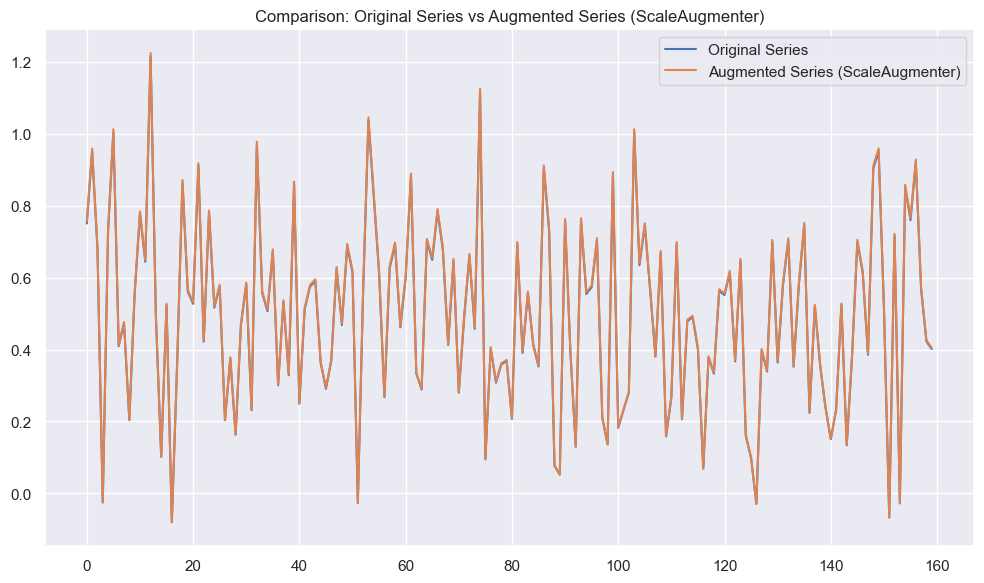

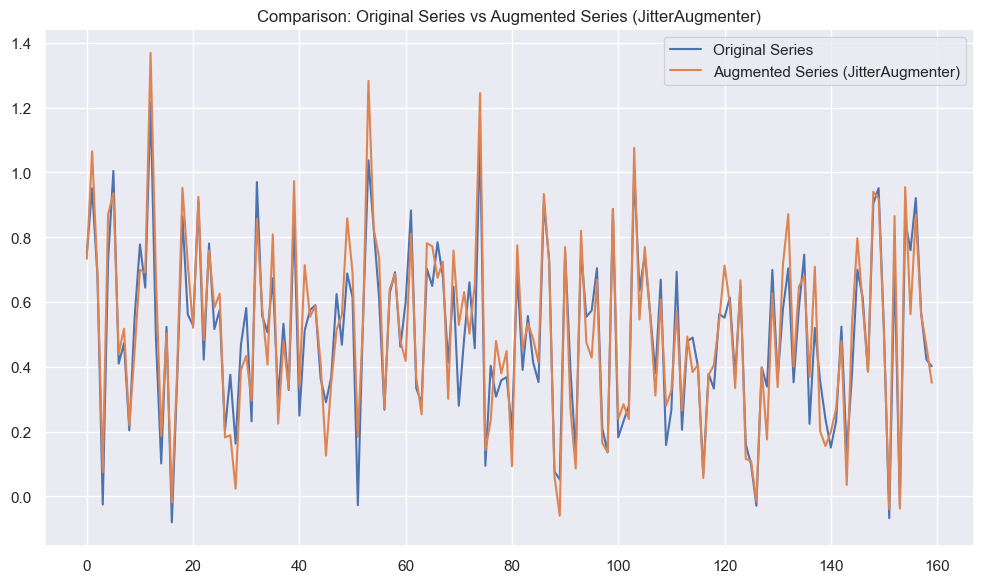

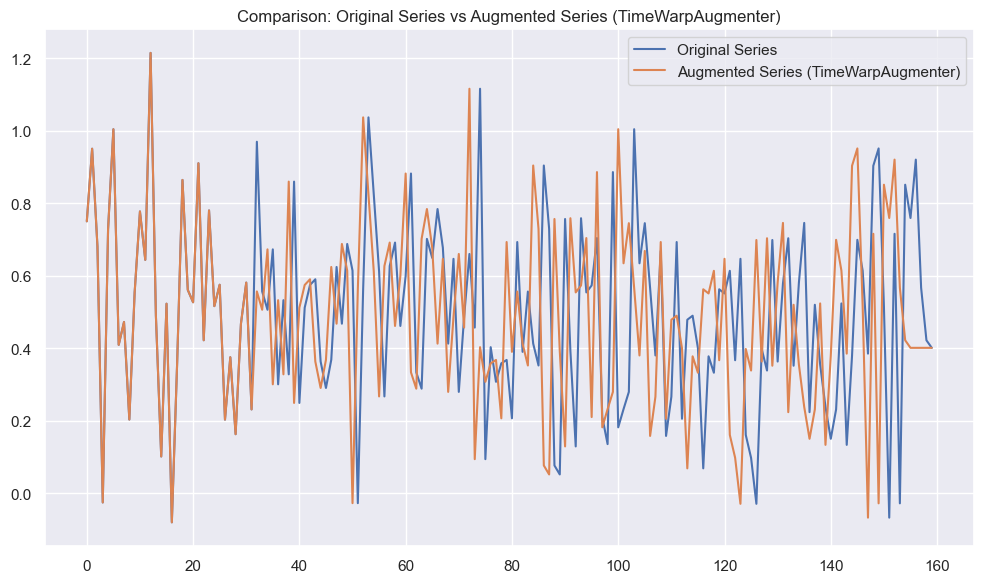

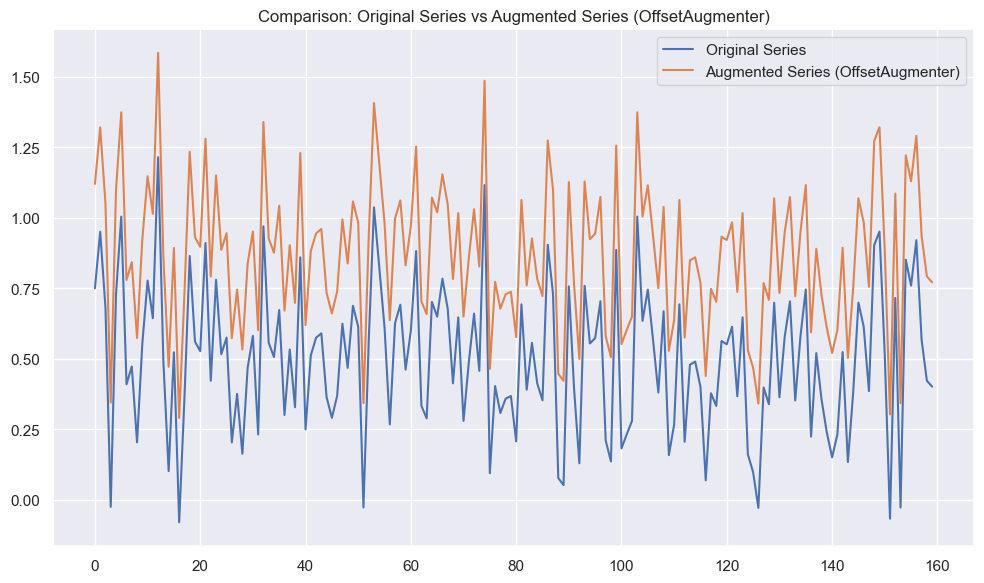

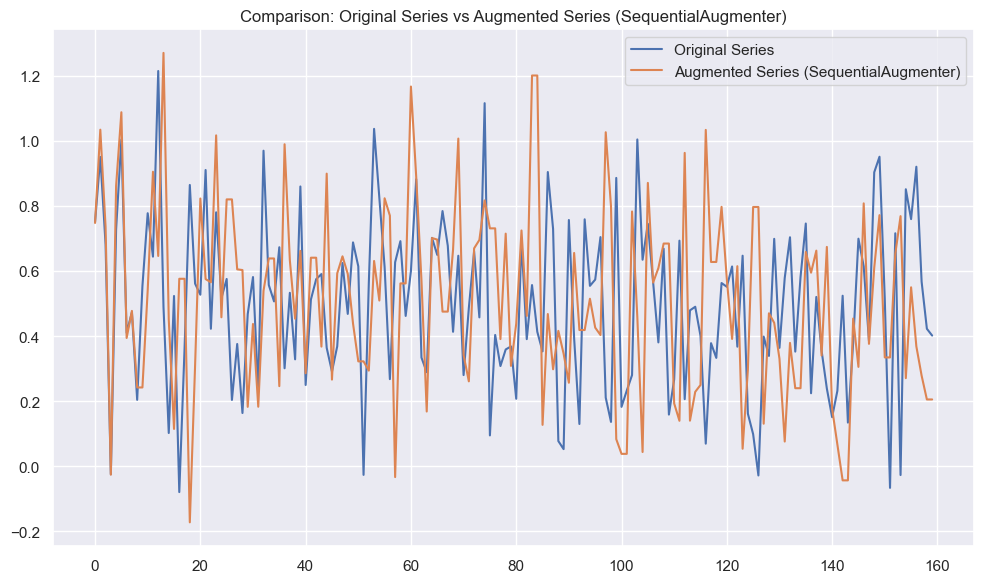

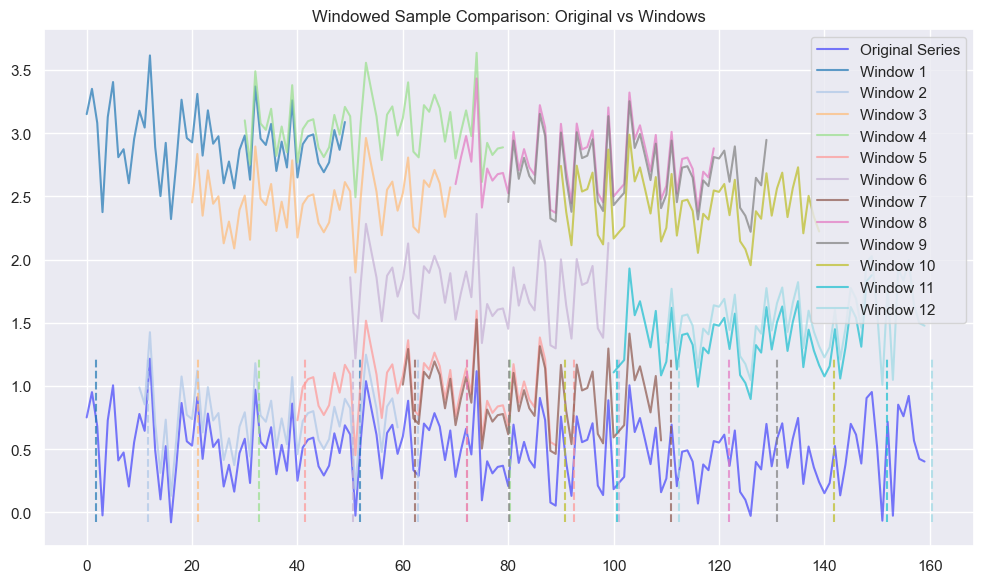

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from GradientGang.TheFreePirate.DataHandling.DataAugmentation.TensorAugmenter import SequentialAugmenter, ScaleAugmenter, JitterAugmenter, WindowingAugmenter, TimeWarpAugmenter, OffsetAugmenter
sns.set_theme()

def plotCompare(series1, series2, title1='Original', title2='Augmented'):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title(f'Comparison: {title1} vs {title2}')
    ax.plot(series1, label=title1)
    ax.plot(series2, label=title2)
    ax.legend()
    plt.tight_layout()
    plt.show()

def testAugmenter(augmenter, sampleTensor, dim=None):
    if dim is None:
        augmentedTensor = augmenter.augment(sampleTensor)
    else:
        augmentedTensor = augmenter.augment(sampleTensor, dim=dim)
    plotCompare(
        series1=sampleTensor.squeeze().numpy(),
        series2=augmentedTensor.squeeze().numpy(),
        title1='Original Series',
        title2=f'Augmented Series ({augmenter.__class__.__name__})'
    )

def plotWindowedSamples(originalTensor, windowedTensor, stride:int):
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title(f'Windowed Sample Comparison: Original vs Windows')
    ax.plot(originalTensor.squeeze().numpy(), label='Original Series', color='blue', alpha=0.5)
    numWindows = windowedTensor.size(-1)
    # windowedTensor has shape (num_windows, window_size)
    numWindows = windowedTensor.size(0)
    windowSize = windowedTensor.size(1)
    for i in range(numWindows):
        start = i * stride
        end = start + windowSize
        color = plt.cm.tab20(i / max(1, numWindows - 1))
        plt.vlines(x=start + np.random.rand() * 3, ymin=originalTensor.min().item(), ymax=originalTensor.max().item(), colors=color, linestyles='dashed', alpha=0.7)
        plt.vlines(x=end + np.random.rand() * 3, ymin=originalTensor.min().item(), ymax=originalTensor.max().item(), colors=color, linestyles='dashed', alpha=0.7)
        ax.plot(range(start, end), windowedTensor[i].detach().cpu().numpy() + np.random.rand() * 3, label=f'Window {i+1}', alpha=0.7, c=color)
    ax.legend()
    plt.tight_layout()
    plt.show()

sampleTensor = tensor[0, :, 0]  # First sample, first feature
testAugmenter(ScaleAugmenter(rangeScale=0.1), sampleTensor)
testAugmenter(JitterAugmenter(jitterStdDev=0.1), sampleTensor)
testAugmenter(TimeWarpAugmenter(maxWarpFraction=0.05), sampleTensor, dim = 0)
testAugmenter(OffsetAugmenter(rangeOffset=0.5), sampleTensor, dim = 0)
testAugmenter(
    SequentialAugmenter(
        augmenters=[
            ScaleAugmenter(rangeScale=0.5),
            JitterAugmenter(jitterStdDev=0.05),
            OffsetAugmenter(rangeOffset=0.1),
            TimeWarpAugmenter(maxWarpFraction=0.2)
        ],
        nCopies=1,
        keepOriginal=False
    ),
    sampleTensor,
    dim = 0
)
windowingAugmenter = WindowingAugmenter(windowSize=50, stride=10)
windowedSample = windowingAugmenter.augment(sampleTensor, dim=0)
plotWindowedSamples(sampleTensor, windowedSample, stride=10)

In [5]:
print("Original Shape", tensor.shape)

augmenter = SequentialAugmenter(
        augmenters=[
            ScaleAugmenter(rangeScale=0.5),
            JitterAugmenter(jitterStdDev=0.1),
            OffsetAugmenter(rangeOffset=0.1),
            TimeWarpAugmenter(maxWarpFraction=0.2),
        ],
        nCopies=1,
        keepOriginal=True
    )

augmentedTensor = augmenter.augment(tensor, dim=1)
print("Augmented Shape", augmentedTensor.shape)

windowingAugmenter = WindowingAugmenter(windowSize=50, stride=1)
windowedTensor = windowingAugmenter.augment(augmentedTensor, dim=1)
print("Windowed Shape", windowedTensor.shape)

Original Shape torch.Size([661, 160, 33])
Augmented Shape torch.Size([1322, 160, 33])
Windowed Shape torch.Size([1322, 111, 50, 33])


In [6]:
dataAugmenter = SequentialAugmenter(
        augmenters=[
            ScaleAugmenter(rangeScale=0.5),
            JitterAugmenter(jitterStdDev=0.1),
            OffsetAugmenter(rangeOffset=0.1),
            TimeWarpAugmenter(maxWarpFraction=0.2),
        ],
        nCopies=2,
        keepOriginal=True
    )

windowingAugmenter = WindowingAugmenter(windowSize=50, stride=5)

dataModule.setupKFolds(nFolds=2, dataAugmenter=dataAugmenter, windowingAugmenter=windowingAugmenter)

[PirateDataModule] Setting up K-Folds(2) with data augmentation...
[PirateDataModule] K-Folds setup completed with 2 folds.


In [7]:
trainLoader, valLoader = dataModule.getFoldDataLoaders(foldIndex=0)

In [8]:
#print (trainLoader, valLoader)
for batch in trainLoader:
    (timeSeriesBatch, globalFeaturesBatch), labelsBatch = batch
    print("Time Series Batch Shape:", timeSeriesBatch.shape)
    print("Global Features Batch Shape:", globalFeaturesBatch.shape)
    print("Labels Batch Shape:", labelsBatch.shape)
    break

for batch in valLoader:
    (timeSeriesBatch, globalFeaturesBatch), labelsBatch = batch
    print("Time Series Batch Shape:", timeSeriesBatch.shape)
    print("Global Features Batch Shape:", globalFeaturesBatch.shape)
    print("Labels Batch Shape:", labelsBatch.shape)
    break

Time Series Batch Shape: torch.Size([32, 23, 50, 33])
Global Features Batch Shape: torch.Size([32, 33])
Labels Batch Shape: torch.Size([32])
Time Series Batch Shape: torch.Size([32, 23, 50, 33])
Global Features Batch Shape: torch.Size([32, 33])
Labels Batch Shape: torch.Size([32])


In [11]:
dataModule.getDataInfoKFold()

{'numFolds': 2,
 'foldSizes': [{'trainSize': 4962, 'valSize': 993},
  {'trainSize': 4965, 'valSize': 990}],
 'shapes': {'train': {'timeSeriesShape': torch.Size([990, 23, 50, 33]),
   'globalFeaturesShape': torch.Size([990, 33]),
   'labelsShape': torch.Size([990])},
  'val': {'timeSeriesShape': torch.Size([993, 23, 50, 33]),
   'globalFeaturesShape': torch.Size([993, 33]),
   'labelsShape': torch.Size([993])}}}